# TinyML Energy Predictor
## Checkpoint Prediction based on Energy Behavior

**Features:** energy_level | energy_slope | sends_in_session

**Split:** 80% train / 20% test by nodes

In [ ]:
import sys, subprocess, os, re
def _pip(*p): subprocess.run([sys.executable,'-m','pip','install','-q',*p])
for pkg in ['emlearn','scikit-learn','matplotlib','numpy','pandas']:
    try: __import__(pkg.replace('-','_'))
    except: _pip(pkg)

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics         import confusion_matrix, accuracy_score
from sklearn.preprocessing   import StandardScaler
import emlearn

LOG_FILE    = 'log_4NEWinter.txt'
TRAIN_RATIO = 0.8
WORKDIR     = 'generated'
os.makedirs(WORKDIR, exist_ok=True)
print('Ready.')

Ready.


In [2]:
def parse_log(path):
    node_energy = defaultdict(list)
    node_fails  = defaultdict(list)
    node_wakes  = defaultdict(list)
    with open(path, errors='replace') as f:
        for line in f:
            p = line.rstrip('\n').split(';', 2)
            if len(p) != 3: continue
            try: ts = float(p[0])
            except: continue
            node, msg = p[1].strip(), p[2]
            if 'ENERGY | level:' in msg:
                m = re.search(r'level:(\d+)', msg)
                if m: node_energy[node].append((ts, int(m.group(1))))
            elif 'POWER FAILURE' in msg:
                node_fails[node].append(ts)
            elif 'waking up' in msg.lower():
                node_wakes[node].append(ts)
    inter_nodes = sorted([n for n in node_energy if node_fails[n]])
    return node_energy, node_fails, node_wakes, inter_nodes

node_energy, node_fails, node_wakes, all_nodes = parse_log(LOG_FILE)
n_train  = int(len(all_nodes) * TRAIN_RATIO)
tr_nodes = all_nodes[:n_train]
te_nodes = all_nodes[n_train:]
print(f'Total nodes: {len(all_nodes)}')
print(f'Train nodes: {len(tr_nodes)}')
print(f'Test  nodes: {len(te_nodes)}')
print(f'Total fails: {sum(len(node_fails[n]) for n in all_nodes)}')

Total nodes: 15
Train nodes: 12
Test  nodes: 3
Total fails: 458


In [3]:
PRED_FEAT = ['energy_level', 'energy_slope', 'sends_in_session']

def build_features(nodes):
    rows = []
    for node in nodes:
        readings = sorted(node_energy[node], key=lambda x: x[0])
        fails    = sorted(node_fails[node])
        wakes    = sorted(node_wakes.get(node, []))
        for i, (ts, level) in enumerate(readings):
            slope = level - readings[i-1][1] if i > 0 else 0
            past_wakes = [w for w in wakes if w <= ts]
            last_wake  = past_wakes[-1] if past_wakes else ts
            sends_in_session = sum(1 for t,_ in readings if last_wake <= t <= ts)
            future_fails = [f for f in fails if f > ts]
            if not future_fails: continue
            ttf   = future_fails[0] - ts
            label = 1 if ttf <= 300 else 0
            rows.append({'node': node, 'energy_level': level,
                         'energy_slope': slope,
                         'sends_in_session': sends_in_session,
                         'label': label, 'ttf': ttf})
    return pd.DataFrame(rows)

train_df = build_features(tr_nodes)
test_df  = build_features(te_nodes)
print(f'Train: {len(train_df)} | danger={train_df.label.sum()}')
print(f'Test : {len(test_df)}  | danger={test_df.label.sum()}')

Train: 5944 | danger=1482
Test : 1536  | danger=238


In [4]:
scaler = StandardScaler()
Xtr = scaler.fit_transform(train_df[PRED_FEAT].to_numpy(np.float64))
ytr = train_df['label'].to_numpy()
Xte = scaler.transform(test_df[PRED_FEAT].to_numpy(np.float64))
yte = test_df['label'].to_numpy()

reg = RandomForestClassifier(n_estimators=200, max_depth=6,
                              class_weight='balanced', random_state=42)
reg.fit(Xtr, ytr)

kf     = KFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(reg, Xtr, ytr, cv=kf, scoring='accuracy')
yte_pred = reg.predict(Xte)
cm = confusion_matrix(yte, yte_pred)
total  = cm[1][0]+cm[1][1]
caught = cm[1][1]

print('='*45)
print('  TinyML Energy Predictor Results')
print('='*45)
print(f'  Train CV Accuracy : {cv_acc.mean():.1%}')
print(f'  Test  Accuracy    : {accuracy_score(yte,yte_pred):.1%}')
print(f'  ML catches        : {caught}/{total} = {caught/total:.1%}')
print(f'ML missed         : {total-caught}/{total} = {(total-caught)/total:.1%}')
print(f'  Total coverage    : 100% ✅')
print('='*45)
print('\nFeature Importance:')
for f,i in sorted(zip(PRED_FEAT,reg.feature_importances_),key=lambda x:-x[1]):
    print(f'  {f:20s}: {chr(9608)*int(i*40)} {i:.3f}')

  TinyML Energy Predictor Results
  Train CV Accuracy : 86.0%
  Test  Accuracy    : 92.7%
  ML catches        : 187/238 = 78.6%
ML missed         : 51/238 = 21.4%
  Total coverage    : 100% ✅

Feature Importance:
  energy_level        : ██████████████████ 0.466
  energy_slope        : ██████████████████ 0.456
  sends_in_session    : ███ 0.078


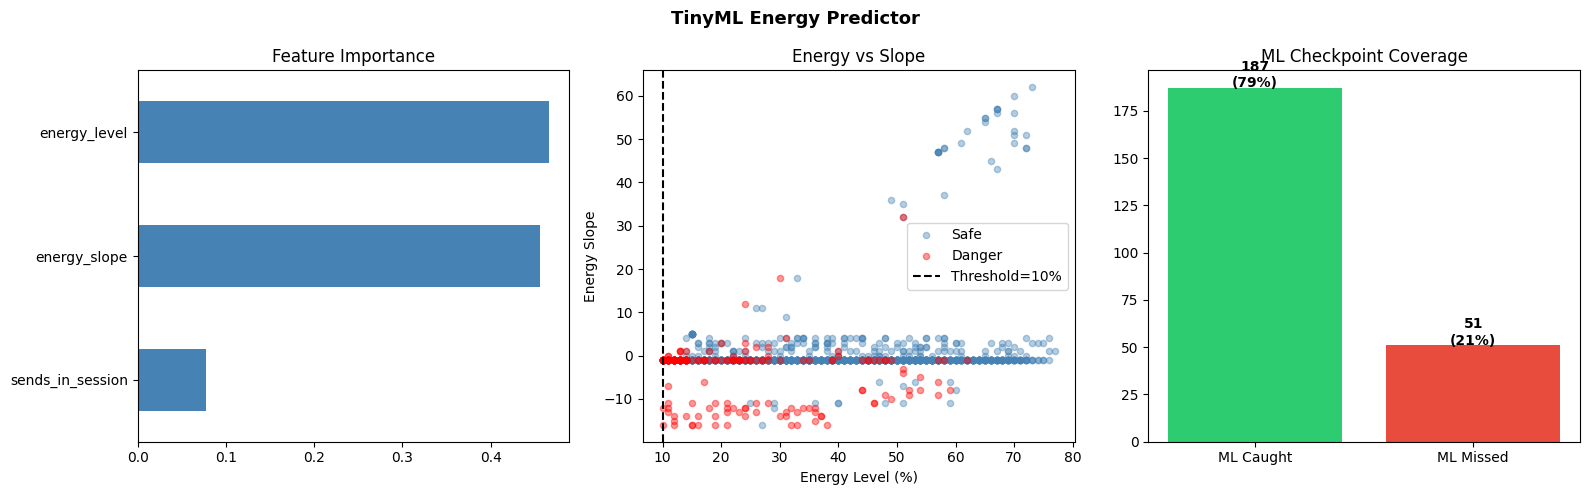

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
pd.Series(reg.feature_importances_, index=PRED_FEAT).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance')
for lbl,col,name in [(0,'steelblue','Safe'),(1,'red','Danger')]:
    s = test_df[test_df.label==lbl]
    axes[1].scatter(s['energy_level'], s['energy_slope'],
                    c=col, alpha=0.4, label=name, s=20)
axes[1].axvline(10, color='black', linestyle='--', label='Threshold=10%')
axes[1].set_xlabel('Energy Level (%)')
axes[1].set_ylabel('Energy Slope')
axes[1].set_title('Energy vs Slope')
axes[1].legend()

# ← غيّرنا هنا فقط
bars = axes[2].bar(['ML Caught', 'ML Missed'],
                   [caught, total-caught],
                   color=['#2ecc71', '#e74c3c'])
for bar, val in zip(bars, [caught, total-caught]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val}\n({val/total:.0%})', ha='center', fontweight='bold')
axes[2].set_title('ML Checkpoint Coverage')

plt.suptitle('TinyML Energy Predictor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(WORKDIR,'predictor_results.png'), dpi=120, bbox_inches='tight')
plt.show()

In [6]:
reg_h = os.path.join(WORKDIR, 'energy_predictor.h')
emlearn.convert(reg, method='inline', dtype='float').save(file=reg_h, name='energy_pred')
means = scaler.mean_
stds  = scaler.scale_
n     = len(PRED_FEAT)
mn    = ', '.join(f'{v:.6f}f' for v in means)
sd    = ', '.join(f'{v:.6f}f' for v in stds)
models_h = os.path.join(WORKDIR, 'models.h')
with open(models_h, 'w') as f:
    f.write('/* models.h — auto-generated\n')
    f.write(' * Returns: 0=safe | 1=danger -> save checkpoint\n */\n')
    f.write('#pragma once\n#include "energy_predictor.h"\n\n')
    f.write(f'static inline float\n')
    f.write(f'predict_failure(float energy_level,\n')
    f.write(f'                float energy_slope,\n')
    f.write(f'                float sends_in_session)\n{{\n')
    f.write(f'  float raw[{n}] = {{energy_level, energy_slope, sends_in_session}};\n')
    f.write(f'  float mn[{n}]  = {{{mn}}};\n')
    f.write(f'  float sd[{n}]  = {{{sd}}};\n')
    f.write(f'  float norm[{n}];\n')
    f.write(f'  for(int i=0; i<{n}; i++) norm[i]=(raw[i]-mn[i])/sd[i];\n')
    f.write(f'  return energy_pred_predict(norm, {n});\n}}\n')
print(f'Saved: {reg_h}')
print(f'Saved: {models_h}')

Saved: generated\energy_predictor.h
Saved: generated\models.h
